In [41]:
# Use local version of systemdynamics instead of installed package
import sys
import os

# Get the parent directory (where systemdynamics package is located)
local_package_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if local_package_path not in sys.path:
    sys.path.insert(0, local_package_path)

# Remove any installed systemdynamics from path to avoid conflicts
for module_name in ['systemdynamics', 'systemdynamics.sdm', 'systemdynamics.cld', 
                    'systemdynamics.equations', 'systemdynamics.optimizer', 'systemdynamics.ltm']:
    sys.modules.pop(module_name, None)

## D2D Example: CLD on Alzheimer's Disease
In this example, we  implement a diagrams-to-dynamics (D2D) analysis of a causal loop diagram (CLD) published by Uleman et al (2020) doi: 10.1007/s11357-020-00228-7. This CLD was turned into a data-driven system dynamics model (SDM) in Uleman (2023) doi: 10.1002/alz.12923. 

In Kumu, the SDM looks as follows:

<img src="Alzheimer CLD.jpg" alt="drawing" width="500"/>

To analyze this CLD, we will first imports the settings and the Kumu file. We will then run the simulations with what-if scenarios, assess the intervention effects, and then perform sensitivity analysis over the model parameters.

In [42]:
import os
from systemdynamics.cld import Extract
from systemdynamics.sdm import SDM
from systemdynamics.plots import plot_simulated_intervention_ranking

current_path = os.getcwd()  # Select current path
file_name = "Alzheimer"  # Specify the relevant name of the CLD Excel file
file_path = os.path.join(current_path, f"{file_name}.xlsx")

extract = Extract(file_path)  # Load the relevant Kumu file extraction module
s = extract.extract_settings()  # Extract the settings using the Kumu Excel file

# Set simulation settings
s.seed = 1912884
s.N = 200  # Number of simulations
s.t_end = 20  # Timeframe of the simulation
s.time_unit = "quarter-years"  # Base unit of time (time unit of t_end)
s.parameter_value_aux = 0.1
s.parameter_value_stocks = 0.1

# Load the module for formulating and simulating the SDM
sdm = SDM(s)  


Variable of interest: Cognitive functioning
with 4 intervention variables
Removed 2.0 incoming links for constant Diabetes
Removed 4.0 incoming links for constant Dyslipidaemia
Removed 6.0 incoming links for constant Social relationships
Removed 1.0 incoming links for constant Hearing loss
Removed 2.0 incoming links for constant Smoking
Removed 1.0 incoming links for constant Excessive alcohol use
Removed 4.0 incoming links for constant Motor function

75 feedback loops of maximum length 5
All loops have at least one stock
Custom equation for 'Neuroinflammation': (1+tanh(-($+#1*Systemic inflammation*Systemic inflammation - #3*Healthy dietary patterns+#7*Systemic inflammation+#4*Oxidative stress + #5* Amyloid beta burden + #6*Head trauma)))/2
  Variables used: {'Amyloid beta burden', 'Head trauma', 'Systemic inflammation', 'Healthy dietary patterns', 'Oxidative stress'}
  Parameters (#): 6
  Intervention ($): Yes - intervention applied within equation

Solving an SDM with interaction te

In [43]:
df_sol, param_samples = sdm.run_simulations()  # Run the simulated interventions
intervention_effects_per_voi = sdm.get_intervention_effects() # Get the intervention effects per variable of interest

Running Simulations: 100%|██████████| 200/200 [00:33<00:00,  5.90it/s]


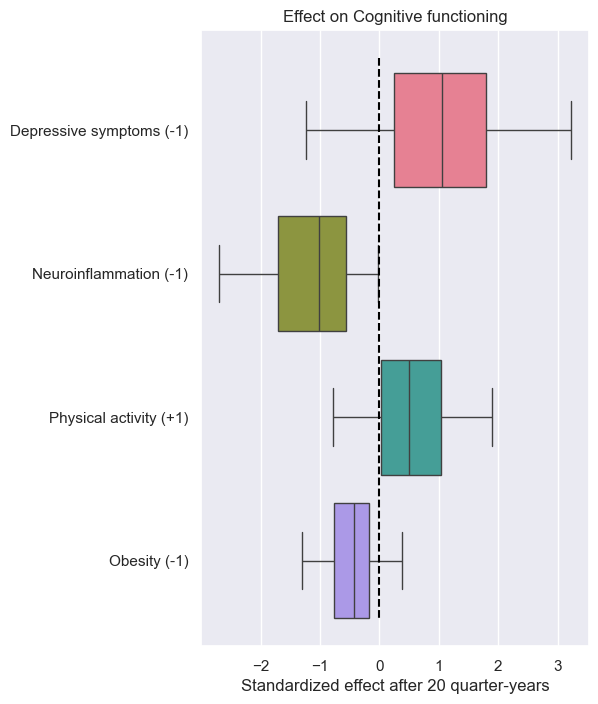

In [15]:
for voi in s.variable_of_interest:
    plot_simulated_intervention_ranking(s, intervention_effects_per_voi[voi], 
                                        voi, top_plot=None, order=None);  # Plot the simulated interventions ranking

Given these settings, we can now run simulations from the SDM-converted CLD.

In [16]:
for voi in s.variable_of_interest:
    print("---- Variable of Interest: ", voi)
    sdm.compare_interventions_table(intervention_effects_per_voi[voi])  # Print the table of the simulated interventions
    print("")

---- Variable of Interest:  Cognitive functioning

Comparison Table (Percentage Greater, 95% CI, Cliff’s Delta):
+---------------------+-------------------+-------------+----------------------+-----------------+
| Intervention A      | Intervention B    |   % Greater | 95% CI (% Greater)   |   Cliff's Delta |
+=====================+===================+=============+======================+=================+
| Depressive symptoms | Neuroinflammation |        48.5 | [41.5, 55.0]         |           -0.03 |
+---------------------+-------------------+-------------+----------------------+-----------------+
| Depressive symptoms | Physical activity |        74.5 | [68.0, 81.0]         |            0.49 |
+---------------------+-------------------+-------------+----------------------+-----------------+
| Depressive symptoms | Obesity           |        67.5 | [61.5, 74.5]         |            0.35 |
+---------------------+-------------------+-------------+----------------------+---------------

## Sensitivity analysis

In [ ]:
## Estimate spearman correlation for the model parameters, either for one intervention variable (int_var) or for all
cut_off_SA_importance = 0.01
int_var = None # If None, the simulations of all intervention will be used

for voi in s.variable_of_interest:
    print("---- Variable of Interest: ", voi)
    outcome_var = voi  # If None, all variables will be used to assess change in the model
    SA_results, df_SA = sdm.run_SA(outcome_var, int_var, cut_off_SA_importance)
    print("")


---- Variable of Interest:  A
+-------+-------+--------------------+------------------+----------------+
| Link  |  Rho  | 95% CI (bootstrap) | Mean Rho per Int | SD Rho per Int |
+-------+-------+--------------------+------------------+----------------+
| p3->A | 0.38  |    [0.16, 0.57]    |       0.36       |      0.64      |
| p2->A | 0.34  |    [0.11, 0.56]    |       0.36       |      0.64      |
| p1->A | -0.05 |   [-0.23, 0.16]    |      -0.06       |      0.02      |
+-------+-------+--------------------+------------------+----------------+



## Optimization of incentives with constaint

This section demonstrates the use of the new optimizer.py class (SDMOptimizer) for optimizing intervention intensities under a budget constraint, using the current parameters and settings from this notebook. The new optimizer supports multi-start SLSQP and robust diagnostics.

In [17]:
# Use the new optimizer_2.py SDMOptimizer for intervention allocation (across parameter samples)
import importlib
import systemdynamics.optimizer_2 as opt2
importlib.reload(opt2)

# Create optimizer instance using the current SDM
optimizer = opt2.SDMOptimizer(sdm)

# Use current costs and variable of interest from notebook
costs = [1.0] * len(s.intervention_variables)  # Equal costs for all interventions
maximize_voi = True  # set False to minimize
voi_name = s.variable_of_interest[0]

# Run optimization across all parameter samples (using new defaults: n_starts=8, slsqp_maxiter=1000, slsqp_ftol=1e-9)
opt_df = optimizer.optimize_across_parameter_samples(
    costs=costs,
    variable_of_interest=voi_name,
    maximize=maximize_voi,
)

print(f"Optimization completed: {len(opt_df)} rows")
print(f"Unique parameter samples: {opt_df['sample_idx'].nunique()}")
print("Columns:", list(opt_df.columns))
if 'success' in opt_df.columns:
    print(f"Success rate: {opt_df.groupby('sample_idx')['success'].max().mean()*100:.1f}%")
else:
    print("No 'success' column found in results!")

# Show summary of optimal intensities
intensity_cols = [col for col in opt_df.columns if col.startswith('intensity_')]
print("\nSummary statistics for optimal intensities:")
display(opt_df[intensity_cols].describe())
print("\nFirst few rows of optimization results:")
display(opt_df.head())

Optimizing across parameter samples (multistart_slsqp): 100%|██████████| 200/200 [07:10<00:00,  2.15s/it]

Optimization completed: 258 rows
Unique parameter samples: 200
Columns: ['sample_idx', 'equilibrium_idx', 'voi_effect_size', 'total_cost', 'n_equilibria', 'success', 'param_Cognitive functioning__Intercept', 'param_Cognitive functioning__Brain atrophy', 'param_Cognitive functioning__Neuronal dysfunction', 'param_Cognitive functioning__Depressive symptoms', 'param_Cognitive functioning__Sleep quality', 'param_Cognitive functioning__Brain perfusion', 'param_Cognitive functioning__Neuronal connectivity', 'param_Cognitive functioning__Hearing loss', 'param_Brain atrophy__Intercept', 'param_Brain atrophy__Neuronal dysfunction', 'param_Neuronal dysfunction__Intercept', 'param_Neuronal dysfunction__Cerebral endothelial dysfunction', 'param_Neuronal dysfunction__Amyloid beta burden', 'param_Neuronal dysfunction__Tau burden', 'param_Neuronal dysfunction__Healthy dietary patterns', 'param_Neuronal dysfunction__Brain perfusion', 'param_Neuronal dysfunction__Oxidative stress', 'param_Neuronal dysf

,intensity_Depressive symptoms,intensity_Obesity,intensity_Physical activity,intensity_Neuroinflammation
count,258.000000,2.580000e+02,258.000000,2.580000e+02
mean,0.648553,1.074922e-02,0.339135,1.383361e-03
std,0.275932,3.847164e-02,0.265433,1.619215e-02
min,0.000000,0.000000e+00,0.000000,0.000000e+00
25%,0.431953,0.000000e+00,0.098949,0.000000e+00
50%,0.688081,8.326673e-17,0.309916,5.551115e-17
75%,0.900780,6.661338e-16,0.533217,4.128642e-16
max,1.000000,3.380295e-01,0.998780,2.251533e-01



First few rows of optimization results:


,sample_idx,equilibrium_idx,voi_effect_size,total_cost,n_equilibria,success,param_Cognitive functioning__Intercept,param_Cognitive functioning__Brain atrophy,param_Cognitive functioning__Neuronal dysfunction,param_Cognitive functioning__Depressive symptoms,...,param_Neuroinflammation__Head trauma,param_Neuronal connectivity__Intercept,param_Neuronal connectivity__Neuronal dysfunction,param_Neuronal connectivity__Engagement in cognitively demanding tasks,param_Neuronal connectivity__Physical activity,param_Neuronal connectivity__Sleep quality,intensity_Depressive symptoms,intensity_Obesity,intensity_Physical activity,intensity_Neuroinflammation
0,0,0,-0.441817,0.999629,1,True,0,-0.083594,-0.060227,-0.006679,...,0.025683,0,-0.065747,0.059561,0.089493,0.034880,0.441617,1.080859e-01,0.449926,3.330669e-16
1,1,0,0.413243,0.999535,1,True,0,-0.007307,-0.005810,-0.012209,...,0.057184,0,-0.041493,0.036114,0.059979,0.046743,0.395061,6.932118e-18,0.604475,1.386992e-17
2,2,0,1.001086,0.999766,1,True,0,-0.052535,-0.009951,-0.024093,...,0.086674,0,-0.094195,0.005929,0.049149,0.086983,0.236684,3.327416e-16,0.763082,0.000000e+00
3,3,0,0.976441,0.999704,1,True,0,-0.009052,-0.090575,-0.079682,...,0.037307,0,-0.050162,0.046370,0.055454,0.059516,0.993350,0.000000e+00,0.006353,0.000000e+00
4,4,0,0.782839,0.999794,1,True,0,-0.007500,-0.009335,-0.047266,...,0.004937,0,-0.026659,0.038023,0.034981,0.082073,0.807887,8.422197e-02,0.107685,0.000000e+00


Plotting top 2 interventions by allocation:
  1. Depressive symptoms: mean = 0.6486
  2. Physical activity: mean = 0.3391


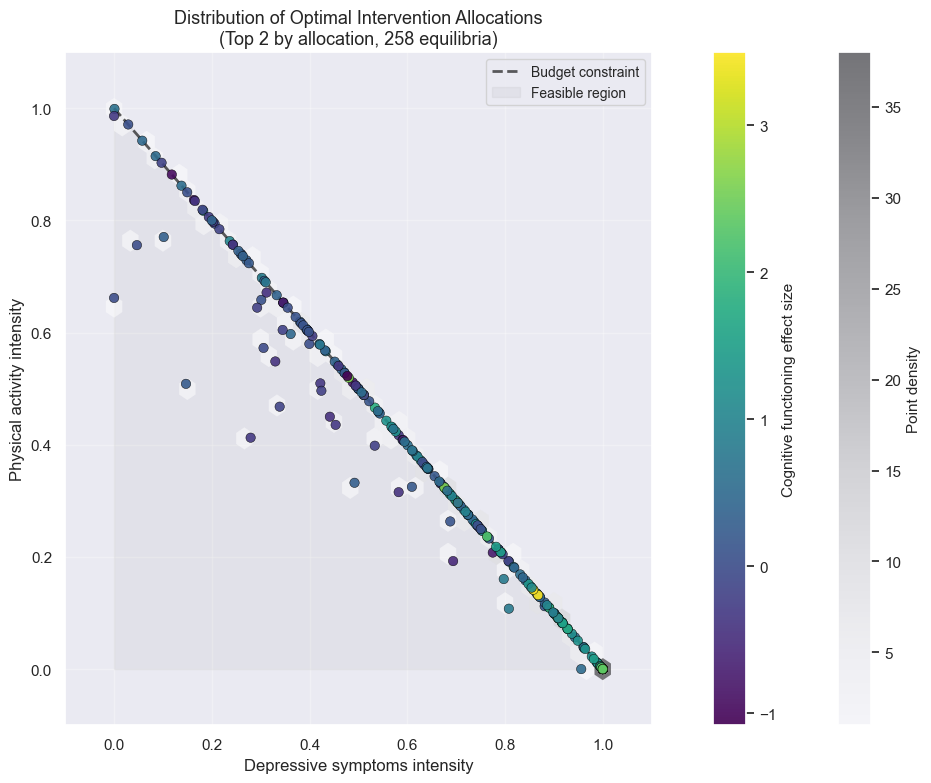


Optimization results summary (258 equilibria):
  Depressive symptoms: mean=0.649, std=0.275, range=[0.000, 1.000]
  Physical activity: mean=0.339, std=0.265, range=[0.000, 0.999]


In [18]:
# Visualize distribution of optimal intensities in 2D simplex (top 2 interventions by mean allocation, using opt_df)
import matplotlib.pyplot as plt
import numpy as np

# Find interventions sorted by mean allocation (highest first)
mean_allocations = {}
for var in s.intervention_variables:
    col = f'intensity_{var}'
    mean_allocations[var] = opt_df[col].mean()

sorted_interventions = sorted(mean_allocations.items(), key=lambda x: x[1], reverse=True)
int_var_1 = sorted_interventions[0][0]  # Highest allocation
int_var_2 = sorted_interventions[1][0]  # Second highest

print(f"Plotting top 2 interventions by allocation:")
print(f"  1. {int_var_1}: mean = {mean_allocations[int_var_1]:.4f}")
print(f"  2. {int_var_2}: mean = {mean_allocations[int_var_2]:.4f}")

# Get cost indices for these variables
cost_1 = costs[s.intervention_variables.index(int_var_1)]
cost_2 = costs[s.intervention_variables.index(int_var_2)]

# Extract intensities from optimization results
x = opt_df[f'intensity_{int_var_1}'].values
y = opt_df[f'intensity_{int_var_2}'].values
effects = opt_df['voi_effect_size'].values

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the feasible region boundary
max_x = 1.0 / cost_1
max_y = 1.0 / cost_2
x_boundary = np.linspace(0, max_x, 100)
y_boundary = (1.0 - x_boundary * cost_1) / cost_2
y_boundary = np.maximum(y_boundary, 0)
ax.plot(x_boundary, y_boundary, 'k--', linewidth=2, label='Budget constraint', alpha=0.7, zorder=2)
ax.fill_between(x_boundary, 0, y_boundary, alpha=0.08, color='gray', label='Feasible region', zorder=1)

# Density layer: hexbin counts to show clustering (grayscale with dark = high density)
hb = ax.hexbin(x, y, gridsize=30, cmap='Greys', mincnt=1, linewidths=0.1, alpha=0.5, zorder=1)
cbar_density = plt.colorbar(hb, ax=ax, pad=0.012)
cbar_density.set_label('Point density', fontsize=11)

# Scatter plot colored by effect size
scatter = ax.scatter(x, y, c=effects, cmap='viridis', s=46, alpha=0.9,
                     edgecolors='black', linewidth=0.35, zorder=3)
cbar_effect = plt.colorbar(scatter, ax=ax, pad=0.08)
cbar_effect.set_label(f'{voi_name} effect size', fontsize=11)

ax.set_xlabel(f'{int_var_1} intensity', fontsize=12)
ax.set_ylabel(f'{int_var_2} intensity', fontsize=12)
ax.set_title(f'Distribution of Optimal Intervention Allocations\n(Top 2 by allocation, {len(opt_df)} equilibria)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Set axis limits based on data with some margin
margin_x = max_x * 0.1
margin_y = max_y * 0.1
ax.set_xlim(left=-margin_x, right=max_x + margin_x)
ax.set_ylim(bottom=-margin_y, top=max_y + margin_y)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nOptimization results summary ({len(opt_df)} equilibria):")
print(f"  {int_var_1}: mean={x.mean():.3f}, std={x.std():.3f}, range=[{x.min():.3f}, {x.max():.3f}]")
print(f"  {int_var_2}: mean={y.mean():.3f}, std={y.std():.3f}, range=[{y.min():.3f}, {y.max():.3f}]")

Detected intensity columns: ['intensity_Depressive symptoms', 'intensity_Obesity', 'intensity_Physical activity', 'intensity_Neuroinflammation']
Detected parameter columns: ['param_Cognitive functioning__Intercept', 'param_Cognitive functioning__Brain atrophy', 'param_Cognitive functioning__Neuronal dysfunction', 'param_Cognitive functioning__Depressive symptoms', 'param_Cognitive functioning__Sleep quality', 'param_Cognitive functioning__Brain perfusion', 'param_Cognitive functioning__Neuronal connectivity', 'param_Cognitive functioning__Hearing loss', 'param_Brain atrophy__Intercept', 'param_Brain atrophy__Neuronal dysfunction', 'param_Neuronal dysfunction__Intercept', 'param_Neuronal dysfunction__Cerebral endothelial dysfunction', 'param_Neuronal dysfunction__Amyloid beta burden', 'param_Neuronal dysfunction__Tau burden', 'param_Neuronal dysfunction__Healthy dietary patterns', 'param_Neuronal dysfunction__Brain perfusion', 'param_Neuronal dysfunction__Oxidative stress', 'param_Neuro

C:\Users\vvvas\AppData\Local\Temp\ipykernel_41164\492902547.py:95: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


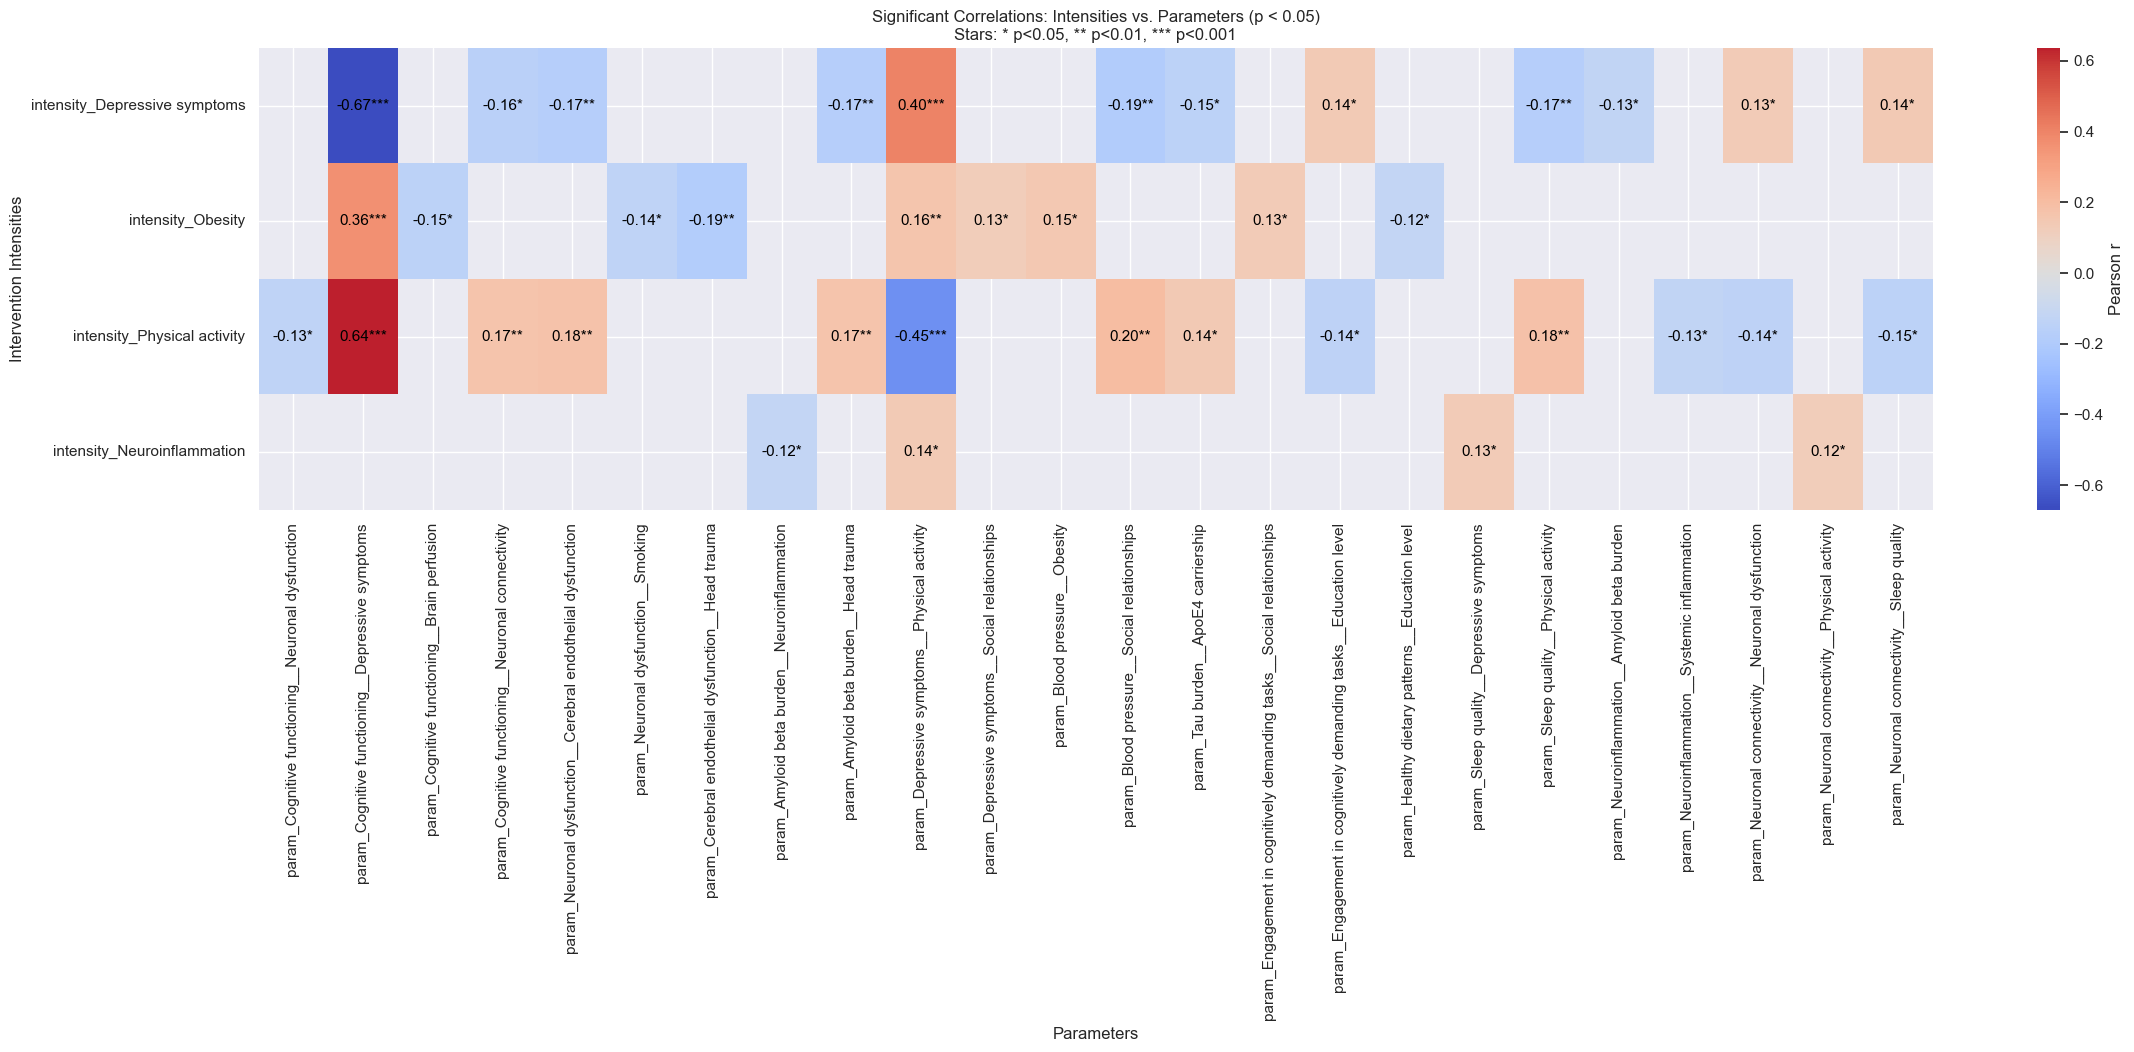

In [19]:
# Visualize only significant, non-NaN cross-correlations between intervention intensities and parameters (using opt_df)
# Add stars to indicate significance level and make non-significant effects transparent
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import re

def pretty_param_name(col):
    # Match custom equation param columns: param_*eq_params_{var}*#N
    m = re.search(r"eq_params_([A-Za-z0-9]+).*#(\d+)", col)
    if m:
        var = m.group(1)
        idx = int(m.group(2))
        return f"p{idx}->{var}"
    return col

def get_intensity_and_param_columns(df):
    intensity_cols = [col for col in df.columns if col.startswith('intensity_')]
    param_cols = [col for col in df.columns if col.startswith('param_') and not col.endswith('_type')]
    return intensity_cols, param_cols

intensity_cols, param_cols = get_intensity_and_param_columns(opt_df)

# Use pretty names for parameter columns
pretty_param_cols = [pretty_param_name(c) for c in param_cols]

print(f"Detected intensity columns: {intensity_cols}")
print(f"Detected parameter columns: {param_cols}")
print(f"Pretty parameter columns: {pretty_param_cols}")

# Compute correlation and p-value matrices
corr_matrix = np.full((len(intensity_cols), len(param_cols)), np.nan)
pval_matrix = np.full((len(intensity_cols), len(param_cols)), np.nan)

for i, int_col in enumerate(intensity_cols):
    for j, par_col in enumerate(param_cols):
        x = opt_df[int_col]
        y = opt_df[par_col]
        mask = x.notna() & y.notna()
        if mask.sum() > 2 and np.nanstd(y[mask]) > 0 and np.nanstd(x[mask]) > 0:
            r, p = pearsonr(x[mask], y[mask])
            corr_matrix[i, j] = r
            pval_matrix[i, j] = p

# Mask for significant and non-NaN correlations (e.g., p < 0.05)
sig_mask = (pval_matrix < 0.05) & ~np.isnan(corr_matrix)

# Filter out columns (parameters) with all NaN or all non-significant
keep_param = np.any(sig_mask, axis=0)
keep_intensity = np.any(sig_mask, axis=1)

filtered_corr = corr_matrix[np.ix_(keep_intensity, keep_param)]
filtered_pval = pval_matrix[np.ix_(keep_intensity, keep_param)]
filtered_sig = sig_mask[np.ix_(keep_intensity, keep_param)]
filtered_intensity = [intensity_cols[i] for i, keep in enumerate(keep_intensity) if keep]
filtered_param = [pretty_param_cols[j] for j, keep in enumerate(keep_param) if keep]

# Prepare annotation matrix with stars for significance, blank for non-significant
def get_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

annotation = np.empty(filtered_corr.shape, dtype=object)
for i in range(filtered_corr.shape[0]):
    for j in range(filtered_corr.shape[1]):
        val = filtered_corr[i, j]
        p = filtered_pval[i, j]
        if np.isnan(val) or p >= 0.05:
            annotation[i, j] = ''
        else:
            stars = get_stars(p)
            annotation[i, j] = f'{val:.2f}{stars}'

# Mask for heatmap: True for cells to be transparent (non-significant)
plot_mask = ~filtered_sig | np.isnan(filtered_corr)

if filtered_corr.size == 0:
    print('No significant correlations found.')
else:
    plt.figure(figsize=(max(8, len(filtered_param) + 3), max(6, len(filtered_intensity) + 2)))
    sns.heatmap(filtered_corr, annot=annotation, fmt='', cmap='coolwarm', center=0,
                xticklabels=filtered_param, yticklabels=filtered_intensity,
                mask=plot_mask, cbar_kws={'label': 'Pearson r'},
                annot_kws={"color": "black", "fontsize": 11, "alpha": 1})
    plt.title('Significant Correlations: Intensities vs. Parameters (p < 0.05)\nStars: * p<0.05, ** p<0.01, *** p<0.001')
    plt.xlabel('Parameters')
    plt.ylabel('Intervention Intensities')
    plt.tight_layout()
    plt.show()

## Optimization with time horizonts

In [20]:
# Optimization across different time horizons using the new optimizer_2.py SDMOptimizer
import importlib
import systemdynamics.optimizer_2 as opt2
importlib.reload(opt2)

# Create optimizer instance using the current SDM
optimizer = opt2.SDMOptimizer(sdm)

# Use current costs and variable of interest from notebook
costs = [1.0] * len(s.intervention_variables)  # Equal costs for all interventions
maximize_voi = True  # set False to minimize
voi_name = s.variable_of_interest[0]

time_horizons = [1, 2, 5, 10, 20]
horizon_results = {}

print("Running optimization across time horizons (equal costs)...")
for t_end in time_horizons:
    # Store original values
    original_t_end = s.t_end
    original_t_span = sdm.t_span.copy()
    original_t_eval = sdm.t_eval.copy()
    
    # Update BOTH s.t_end AND sdm internal state
    s.t_end = t_end
    sdm.t_span = [0.0, t_end]
    sdm.t_eval = np.array(sdm.t_span)
    
    # Run optimization for this time horizon using the new optimizer
    opt_df = optimizer.optimize_across_parameter_samples(
        costs=costs,
        variable_of_interest=voi_name,
        maximize=maximize_voi,
    )
    
    # Restore original values
    s.t_end = original_t_end
    sdm.t_span = original_t_span
    sdm.t_eval = original_t_eval
    
    # Store results
    horizon_results[t_end] = opt_df
    
print("\nOptimization complete for all time horizons!")

Running optimization across time horizons (equal costs)...


Optimizing across parameter samples (multistart_slsqp): 100%|██████████| 200/200 [04:40<00:00,  1.40s/it]
Optimizing across parameter samples (multistart_slsqp): 100%|██████████| 200/200 [05:08<00:00,  1.54s/it]
Optimizing across parameter samples (multistart_slsqp): 100%|██████████| 200/200 [05:35<00:00,  1.68s/it]
Optimizing across parameter samples (multistart_slsqp): 100%|██████████| 200/200 [04:16<00:00,  1.28s/it]
Optimizing across parameter samples (multistart_slsqp): 100%|██████████| 200/200 [04:44<00:00,  1.42s/it]


Optimization complete for all time horizons!


Mean allocations by intervention and time horizon:
Intervention                   | t=  1 | t=  2 | t=  5 | t= 10 | t= 20
-------------------------------------------------------------------------------------
Depressive symptoms            | 0.519 | 0.568 | 0.631 | 0.702 | 0.654
Obesity                        | 0.119 | 0.102 | 0.067 | 0.041 | 0.013
Physical activity              | 0.189 | 0.230 | 0.263 | 0.240 | 0.332
Neuroinflammation              | 0.114 | 0.087 | 0.036 | 0.018 | 0.001

4 interventions with mean allocation > 0.01

Selected for visualization:
  1. Depressive symptoms: max mean = 0.7016
  2. Physical activity: max mean = 0.3318


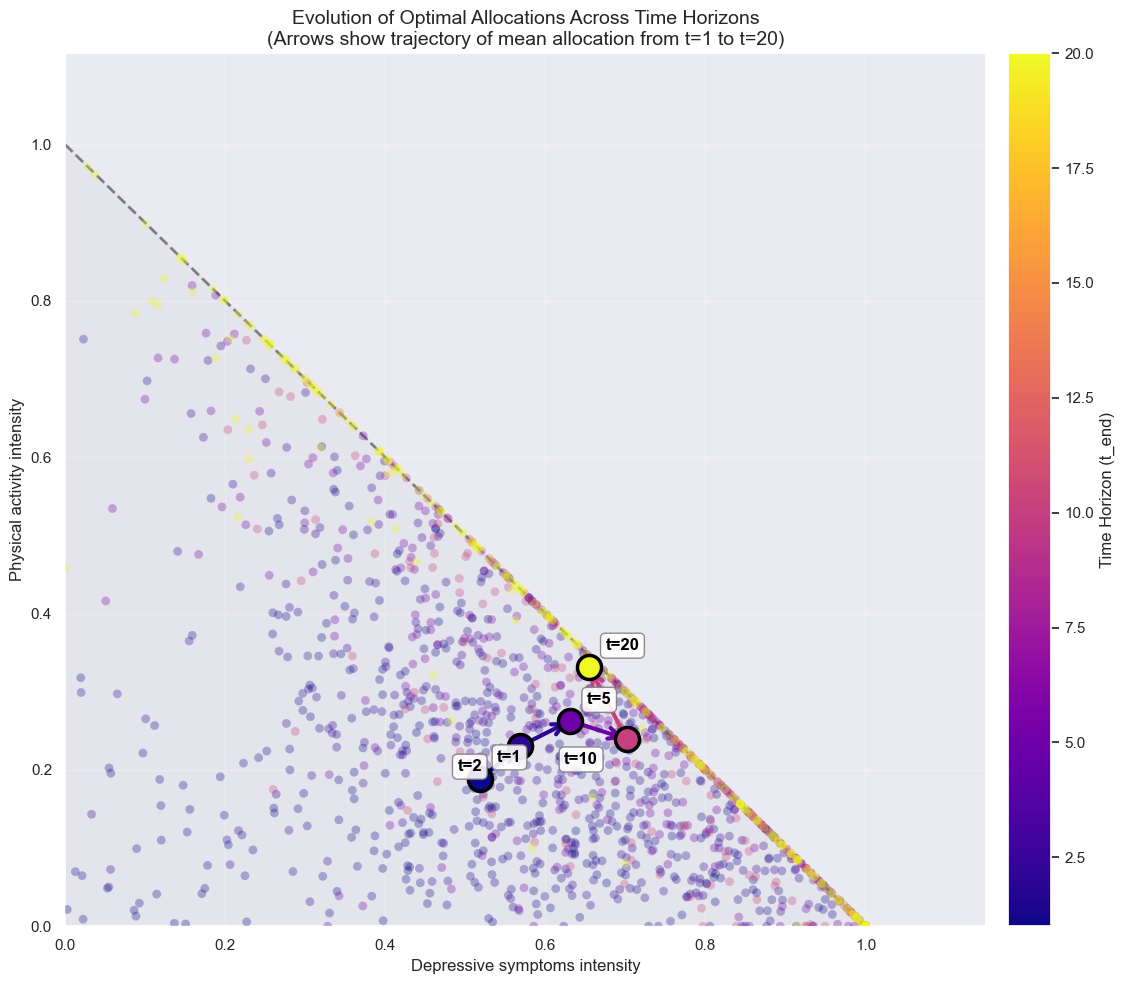


Trajectory of mean optimal allocations:
 t_end |  n_samples |  Mean Effect | Depressive symp | Physical activi
----------------------------------------------------------------------
     1 |        367 |       0.0342 |          0.5189 |          0.1889
     2 |        350 |       0.0680 |          0.5683 |          0.2303
     5 |        262 |       0.1640 |          0.6310 |          0.2625
    10 |        226 |       0.4364 |          0.7016 |          0.2395
    20 |        255 |       0.9433 |          0.6544 |          0.3318


In [23]:
# Analyze which interventions have actual variation across time horizons
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Calculate mean allocation per intervention per time horizon
mean_allocations = {}
for var in s.intervention_variables:
    col = f'intensity_{var}'
    mean_allocations[var] = [horizon_results[t][col].mean() for t in time_horizons]

# Print summary of all interventions
print("Mean allocations by intervention and time horizon:")
print(f"{'Intervention':<30} | " + " | ".join([f"t={t:>3}" for t in time_horizons]))
print("-" * (35 + 10 * len(time_horizons)))
for var in s.intervention_variables:
    means = mean_allocations[var]
    if max(means) > 0.001:  # Only show if non-zero
        print(f"{var:<30} | " + " | ".join([f"{m:>5.3f}" for m in means]))

# Find interventions with actual allocation
active_interventions = [var for var in s.intervention_variables 
                        if max(mean_allocations[var]) > 0.01]
print(f"\n{len(active_interventions)} interventions with mean allocation > 0.01")

# Select top 2 interventions by maximum mean allocation
sorted_by_max = sorted(s.intervention_variables, 
                       key=lambda v: max(mean_allocations[v]), reverse=True)
int_var_1 = sorted_by_max[0]
int_var_2 = sorted_by_max[1]

print(f"\nSelected for visualization:")
print(f"  1. {int_var_1}: max mean = {max(mean_allocations[int_var_1]):.4f}")
print(f"  2. {int_var_2}: max mean = {max(mean_allocations[int_var_2]):.4f}")

# Recalculate modes for these two variables
modes = {}
means_plot = {}
for t_end, opt_df in horizon_results.items():
    x = opt_df[f'intensity_{int_var_1}'].values
    y = opt_df[f'intensity_{int_var_2}'].values
    means_plot[t_end] = (x.mean(), y.mean())
    
    # Use mean as mode proxy (more robust when data clusters)
    modes[t_end] = means_plot[t_end]

# Get cost indices for these variables
cost_1 = costs[s.intervention_variables.index(int_var_1)]
cost_2 = costs[s.intervention_variables.index(int_var_2)]

fig, ax = plt.subplots(figsize=(12, 10))

# Plot the feasible region boundary (partial budget constraint for these 2 vars)
max_x = 1.0 / cost_1
max_y = 1.0 / cost_2
x_boundary = np.linspace(0, max_x, 100)
y_boundary = (1.0 - x_boundary * cost_1) / cost_2
y_boundary = np.maximum(y_boundary, 0)
ax.plot(x_boundary, y_boundary, 'k--', linewidth=2, label='Budget constraint', alpha=0.5, zorder=2)
ax.fill_between(x_boundary, 0, y_boundary, alpha=0.05, color='gray', zorder=1)

# Color map for time horizons
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=min(time_horizons), vmax=max(time_horizons))

# Plot scatter for each time horizon
for t_end, opt_df in horizon_results.items():
    x = opt_df[f'intensity_{int_var_1}'].values
    y = opt_df[f'intensity_{int_var_2}'].values
    color = cmap(norm(t_end))
    ax.scatter(x, y, c=[color], s=40, alpha=0.3, edgecolors='none', zorder=3)

# Plot mean trajectory with arrows
mean_x = [means_plot[t][0] for t in time_horizons]
mean_y = [means_plot[t][1] for t in time_horizons]

# Draw arrows between consecutive means
for i in range(len(time_horizons) - 1):
    t_start = time_horizons[i]
    dx = mean_x[i + 1] - mean_x[i]
    dy = mean_y[i + 1] - mean_y[i]
    
    color = cmap(norm(t_start))
    
    # Draw arrow
    dist = np.sqrt(dx**2 + dy**2)
    if dist > 0.001:
        ax.annotate('', 
                    xy=(mean_x[i + 1], mean_y[i + 1]),
                    xytext=(mean_x[i], mean_y[i]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=3, 
                                   mutation_scale=20),
                    zorder=5)

# Plot mean points with labels
for i, t_end in enumerate(time_horizons):
    color = cmap(norm(t_end))
    ax.scatter(mean_x[i], mean_y[i], c=[color], s=300, edgecolors='black', 
               linewidth=2.5, zorder=6, marker='o')
    # Add time label
    offset = (12, 12) if i % 2 == 0 else (-45, -18)
    ax.annotate(f't={t_end}', (mean_x[i], mean_y[i]), 
                xytext=offset, textcoords='offset points',
                fontsize=12, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='gray'),
                zorder=7)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Time Horizon (t_end)', fontsize=12)

ax.set_xlabel(f'{int_var_1} intensity', fontsize=12)
ax.set_ylabel(f'{int_var_2} intensity', fontsize=12)
ax.set_title(f'Evolution of Optimal Allocations Across Time Horizons\n'
             f'(Arrows show trajectory of mean allocation from t=1 to t=20)', fontsize=14)
ax.grid(True, alpha=0.3)

# Set axis limits based on data range
all_x = np.concatenate([horizon_results[t][f'intensity_{int_var_1}'].values for t in time_horizons])
all_y = np.concatenate([horizon_results[t][f'intensity_{int_var_2}'].values for t in time_horizons])
x_range = all_x.max() - all_x.min() if all_x.max() > all_x.min() else 0.1
y_range = all_y.max() - all_y.min() if all_y.max() > all_y.min() else 0.1
margin_x = x_range * 0.15
margin_y = y_range * 0.15
ax.set_xlim(left=max(0, all_x.min() - margin_x), right=all_x.max() + margin_x)
ax.set_ylim(bottom=max(0, all_y.min() - margin_y), top=all_y.max() + margin_y)

plt.tight_layout()
plt.show()

# Summary statistics table
print("\nTrajectory of mean optimal allocations:")
print(f"{'t_end':>6} | {'n_samples':>10} | {'Mean Effect':>12} | {int_var_1[:15]:>15} | {int_var_2[:15]:>15}")
print("-" * 70)
for t_end in time_horizons:
    opt_df = horizon_results[t_end]
    n = len(opt_df)
    mean_effect = opt_df['voi_effect_size'].mean()
    print(f"{t_end:>6} | {n:>10} | {mean_effect:>12.4f} | {means_plot[t_end][0]:>15.4f} | {means_plot[t_end][1]:>15.4f}")

## Loops That Matter (LTM) Analysis
The Loops That Matter method quantitatively identifies which feedback loops are most responsible for the model's behavior at each time point. It computes:
1. **Link scores**: contribution of each causal link to variable changes
2. **Loop scores**: product of link scores around feedback loops
3. **Relative loop scores**: normalized measure of loop dominance (can go beyond -1 or 1)

In [44]:
# Initialize LTM analysis
from systemdynamics.ltm import LoopsThatMatter

ltm = LoopsThatMatter(sdm)
#ltm.print_loops()  # Show identified feedback loops

In [45]:
# Reload LTM module to get updates
import importlib
import pandas as pd
import systemdynamics.ltm
from systemdynamics import ltm as ltm_module  # Import first to ensure it's loaded
importlib.reload(ltm_module)
from systemdynamics.ltm import LoopsThatMatter

# Re-initialize LTM
ltm = LoopsThatMatter(sdm)

# Run LTM analysis using optimal intervention intensities from the optimization
# Get the best intervention allocation from opt_df (highest effect size)
best_idx = opt_df['voi_effect_size'].idxmax()
best_row = opt_df.loc[best_idx]

# Extract optimal intensities as a list of floats
optimal_intensities = []
for var in s.intervention_variables:
    col_name = f'intensity_{var}'
    val = best_row[col_name] if col_name in best_row else 0.0
    # Handle NaN values
    if pd.isna(val):
        val = 0.0
    optimal_intensities.append(float(val))

print(f"Using optimal intervention intensities (effect size = {best_row['voi_effect_size']:.4f}):")
for var, intensity in zip(s.intervention_variables, optimal_intensities):
    if intensity > 0.01:
        print(f"  {var}: {intensity:.4f}")

# Run LTM analysis with these interventions
params = sdm.sample_model_parameters()
df_sol_ltm, link_scores_df, loop_scores_df = ltm.run_ltm_analysis(
    params, 
    t_start=0, 
    t_end=s.t_end, 
    n_points=50,
    intervention_intensities=optimal_intensities
)

# Display loop scores over time
print("\nLoop scores over time (first 10 rows):")
display(loop_scores_df.head(10))

Using optimal intervention intensities (effect size = 3.6222):
  Depressive symptoms: 0.9996

Loop scores over time (first 10 rows):


,time,R1_raw,R1_relative,R2_raw,R2_relative,R3_raw,R3_relative,R4_raw,R4_relative,R5_raw,...,R3154_raw,R3154_relative,R3155_raw,R3155_relative,R3156_raw,R3156_relative,R3157_raw,R3157_relative,R3158_raw,R3158_relative
0,0.408163,0.000938,0.000369,0.000002,9.356147e-07,2.865122e-09,1.126950e-09,0.000096,0.000038,1.158758e-07,...,0.056103,0.022067,0.001055,0.000415,0.005571,0.002191,0.006078,0.002391,0.036662,0.014420
1,0.816327,0.001480,0.000581,0.000004,1.509835e-06,4.344660e-09,1.706971e-09,0.000145,0.000057,1.635182e-07,...,0.091646,0.036007,0.001739,0.000683,0.005267,0.002069,0.005656,0.002222,0.037536,0.014747
2,1.224490,0.001988,0.000780,0.000005,2.071911e-06,5.591529e-09,2.193835e-09,0.000186,0.000073,1.968558e-07,...,0.127076,0.049858,0.002432,0.000954,0.004994,0.001959,0.005291,0.002076,0.038393,0.015064
3,1.632653,0.002470,0.000967,0.000007,2.625999e-06,6.634010e-09,2.598104e-09,0.000222,0.000087,2.194734e-07,...,0.162537,0.063655,0.003133,0.001227,0.004747,0.001859,0.004971,0.001947,0.039233,0.015365
4,2.040816,0.002933,0.001146,0.000008,3.176000e-06,7.493978e-09,2.927903e-09,0.000254,0.000099,2.339131e-07,...,0.198214,0.077442,0.003844,0.001502,0.004524,0.001768,0.004691,0.001833,0.040056,0.015650
5,2.448980,0.003382,0.001317,0.000010,3.724747e-06,8.194834e-09,3.191744e-09,0.000283,0.000110,2.422067e-07,...,0.234312,0.091260,0.004567,0.001779,0.004321,0.001683,0.004441,0.001730,0.040862,0.015915
6,2.857143,0.003824,0.001483,0.000011,4.274871e-06,8.755083e-09,3.396373e-09,0.000309,0.000120,2.458228e-07,...,0.271046,0.105147,0.005303,0.002057,0.004135,0.001604,0.004219,0.001637,0.041651,0.016158
7,3.265306,0.004261,0.001645,0.000013,4.828223e-06,9.187228e-09,3.546761e-09,0.000335,0.000129,2.457731e-07,...,0.308647,0.119154,0.006053,0.002337,0.003964,0.001530,0.004020,0.001552,0.042423,0.016377
8,3.673469,0.004698,0.001803,0.000014,5.386643e-06,9.505396e-09,3.648228e-09,0.000359,0.000138,2.429233e-07,...,0.347374,0.133324,0.006821,0.002618,0.003807,0.001461,0.003840,0.001474,0.043177,0.016572
9,4.081633,0.005138,0.001959,0.000016,5.951296e-06,9.718563e-09,3.704601e-09,0.000382,0.000146,2.378527e-07,...,0.387519,0.147718,0.007609,0.002900,0.003661,0.001396,0.003678,0.001402,0.043914,0.016740


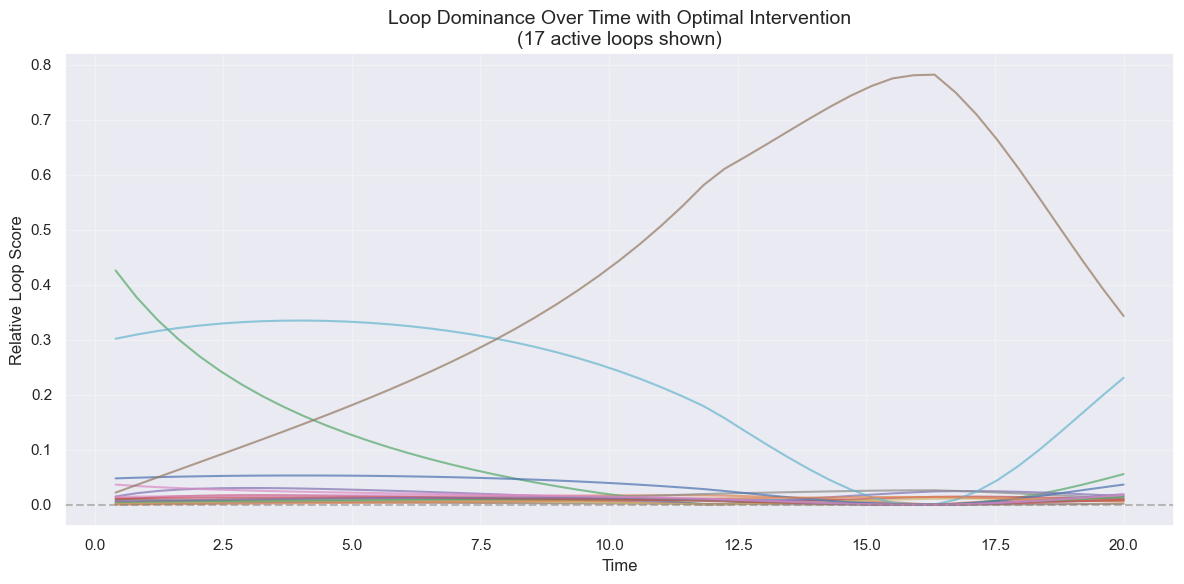


Dominant loops at key time points:
  t=0.1: R661 (score=0.426)
  t=5.0: R3030 (score=0.333)
  t=10.0: R3154 (score=0.416)
  t=15.0: R3154 (score=0.762)
  t=20.0: R3154 (score=0.343)


In [46]:
# Plot loop dominance over time with optimal intervention
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Plot relative scores for each loop (limit to loops with non-zero scores)
active_loops = []
for loop_name in ltm.loop_names:
    col = f'{loop_name}_relative'
    if col in loop_scores_df.columns:
        max_score = loop_scores_df[col].abs().max()
        if max_score > 0.01:  # Only plot loops with meaningful scores
            active_loops.append(loop_name)
            color = 'red' if loop_name.startswith('R') else 'blue'
            ax.plot(loop_scores_df['time'], loop_scores_df[col], 
                    label=loop_name, alpha=0.7, linewidth=1.5)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Relative Loop Score', fontsize=12)
ax.set_title(f'Loop Dominance Over Time with Optimal Intervention\n({len(active_loops)} active loops shown)', fontsize=14)
if len(active_loops) <= 15:
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show which loop is dominant at key time points
print("\nDominant loops at key time points:")
for t in [0.1, s.t_end/4, s.t_end/2, 3*s.t_end/4, s.t_end]:
    dom_loop, score = ltm.get_dominant_loop_at_time(t)
    if dom_loop:
        print(f"  t={t:.1f}: {dom_loop} (score={score:.3f})")

In [47]:
# Run LTM across multiple parameter samples WITH the optimal intervention
# This shows how loop dominance varies across parameter uncertainty
ltm_results_df = ltm.run_ltm_across_samples(
    n_samples=min(1000, s.N), 
    n_points=30,
    intervention_intensities=optimal_intensities
)

# Aggregate loop scores across samples
print("Aggregated loop dominance across parameter samples:")
loop_cols = [col for col in ltm_results_df.columns if '_relative' in col]
agg_stats = ltm_results_df.groupby('time')[loop_cols].agg(['mean', 'std'])
display(agg_stats.head())

Running LTM across samples: 100%|██████████| 200/200 [05:13<00:00,  1.57s/it]


Aggregated loop dominance across parameter samples:


R1_relative           R2_relative           R3_relative            \
                mean       std        mean       std        mean       std   
time                                                                         
0.689655    0.002472  0.005365    0.000219  0.001402    0.000009  0.000039   
1.379310    0.002665  0.005874    0.000208  0.001314    0.000008  0.000026   
2.068966    0.002780  0.006463    0.000189  0.001130    0.000007  0.000024   
2.758621    0.002903  0.006882    0.000180  0.000958    0.000007  0.000021   
3.448276    0.003012  0.007145    0.000175  0.000813    0.000007  0.000021   

         R4_relative           R5_relative            ... R3154_relative  \
                mean       std        mean       std  ...           mean   
time                                                  ...                  
0.689655    0.000229  0.000681    0.000013  0.000043  ...       0.030039   
1.379310    0.000214  0.000692    0.000012  0.000035  ...       0.030495   
2.068966    0.000204  0.000735    0.000011  0.000029  ...       0.031399   
2.758621    0.000212  0.000805    0.000011  0.000028  ...       0.030254   
3.448276    0.000223  0.000866    0.000011  0.000028  ...       0.029852   

                   R3155_relative           R3156_relative            \
               std           mean       std           mean       std   
time                                                                   
0.689655  0.069013       0.011598  0.019673       0.003314  0.005462   
1.379310  0.071218       0.010794  0.017669       0.002538  0.004196   
2.068966  0.078036       0.009986  0.016146       0.002105  0.003604   
2.758621  0.074450       0.009252  0.014944       0.001814  0.003296   
3.448276  0.071714       0.009002  0.012749       0.001588  0.002939   

         R3157_relative           R3158_relative            
                   mean       std           mean       std  
time                                                        
0.689655       0.024995  0.036554       0.023248  0.049079  
1.379310       0.019266  0.027345       0.017914  0.028414  
2.068966       0.017932  0.025102       0.015939  0.023983  
2.758621       0.017381  0.025521       0.015513  0.022909  
3.448276       0.017222  0.026025       0.015629  0.023408  

[5 rows x 6316 columns]

=== Loop Selection (Top 5 by peak + Top 5 by avg, union) ===

Reinforcing loops (5 selected):
  Loop     |     Peak |      Avg | Selected by
  ---------------------------------------------
  R661     |   0.2075 |   0.1802 | peak + avg
  R3030    |   0.1611 |   0.1563 | peak + avg
  R2805    |   0.0815 |   0.0338 | peak + avg
  R3154    |   0.0382 |   0.0333 | peak + avg
  R3017    |   0.0359 |   0.0252 | peak + avg

Balancing loops (0 selected):
  Loop     |     Peak |      Avg | Selected by
  ---------------------------------------------


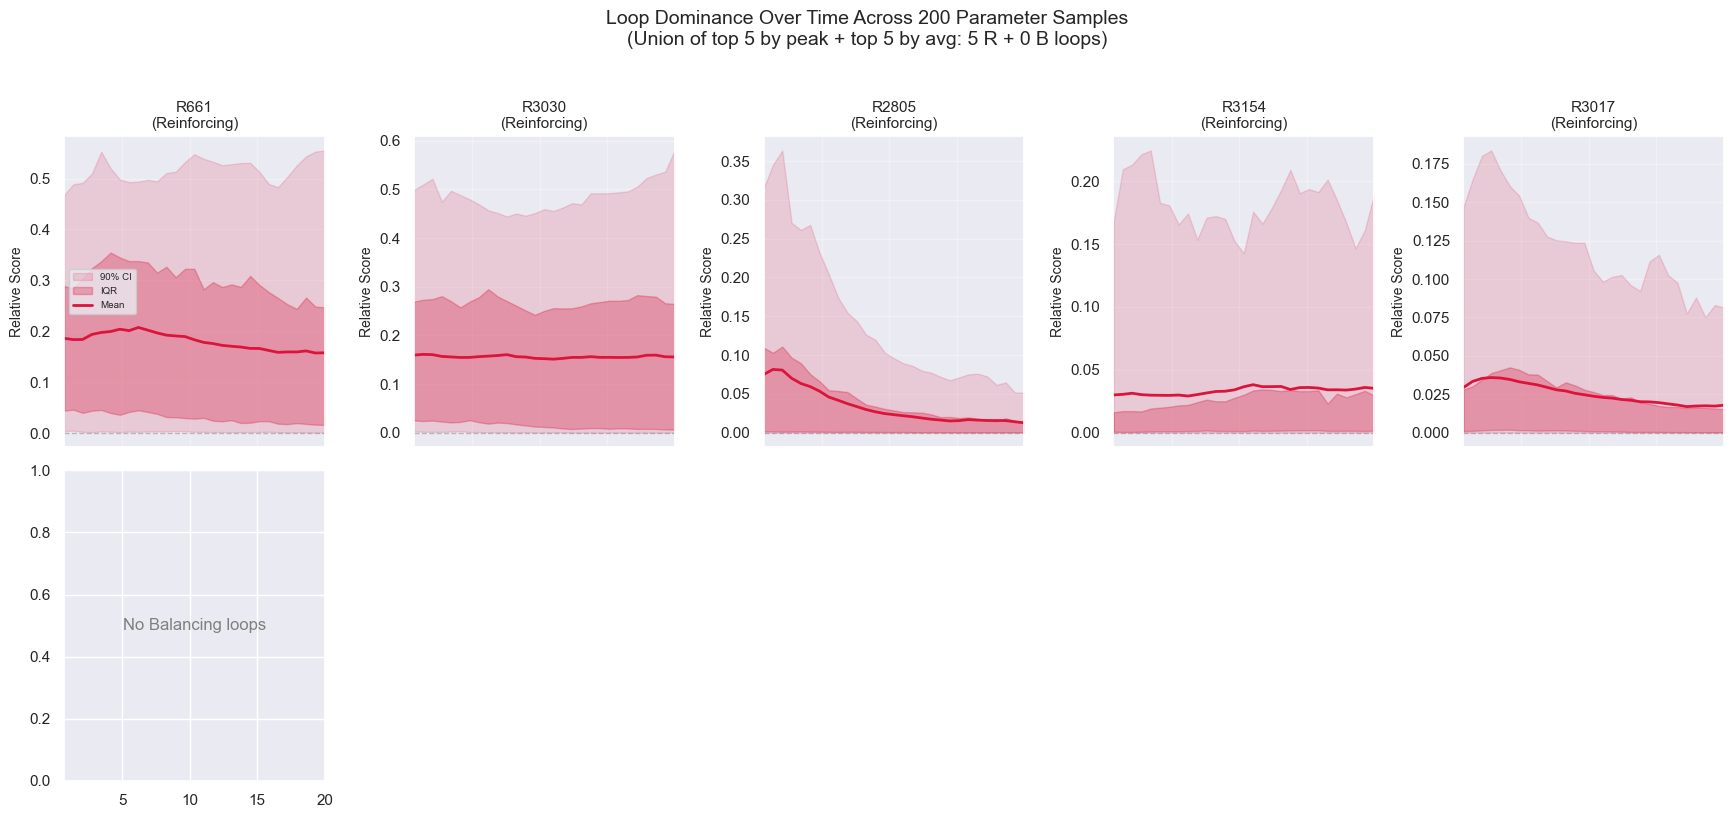


Loop Dominance Summary:
  Reinforcing loops plotted: 5
  Balancing loops plotted: 0
  Total unique loops: 5


In [48]:
# Plot loop effects across samples over time with uncertainty bands
# Top 5 by peak influence + Top 5 by sustained influence → union of 5-10 loops
import matplotlib.pyplot as plt
import numpy as np

# Get loop columns (relative scores)
loop_cols = [col for col in ltm_results_df.columns if '_relative' in col]

# Compute statistics per time point for all loops
times = ltm_results_df['time'].unique()
loop_stats = {}
for col in loop_cols:
    grouped = ltm_results_df.groupby('time')[col]
    mean_vals = grouped.mean().values
    loop_stats[col] = {
        'mean': mean_vals,
        'std': grouped.std().values,
        'q05': grouped.quantile(0.05).values,
        'q25': grouped.quantile(0.25).values,
        'q75': grouped.quantile(0.75).values,
        'q95': grouped.quantile(0.95).values,
        'max_abs_mean': np.abs(mean_vals).max(),      # Peak influence
        'avg_abs_mean': np.abs(mean_vals).mean()      # Sustained influence
    }

# Separate into reinforcing and balancing loops
reinforcing_cols = [col for col in loop_cols if col.replace('_relative', '').startswith('R')]
balancing_cols = [col for col in loop_cols if col.replace('_relative', '').startswith('B')]

# Get top 5 reinforcing by each criterion
top5_r_by_peak = sorted(reinforcing_cols, key=lambda c: loop_stats[c]['max_abs_mean'], reverse=True)[:5]
top5_r_by_avg = sorted(reinforcing_cols, key=lambda c: loop_stats[c]['avg_abs_mean'], reverse=True)[:5]
top_reinforcing = list(set(top5_r_by_peak) | set(top5_r_by_avg))

# Get top 5 balancing by each criterion
top5_b_by_peak = sorted(balancing_cols, key=lambda c: loop_stats[c]['max_abs_mean'], reverse=True)[:5]
top5_b_by_avg = sorted(balancing_cols, key=lambda c: loop_stats[c]['avg_abs_mean'], reverse=True)[:5]
top_balancing = list(set(top5_b_by_peak) | set(top5_b_by_avg))

# Sort selected loops by their max strength for consistent ordering
top_reinforcing.sort(key=lambda c: loop_stats[c]['max_abs_mean'], reverse=True)
top_balancing.sort(key=lambda c: loop_stats[c]['max_abs_mean'], reverse=True)

print("=== Loop Selection (Top 5 by peak + Top 5 by avg, union) ===")
print(f"\nReinforcing loops ({len(top_reinforcing)} selected):")
print(f"  {'Loop':<8} | {'Peak':>8} | {'Avg':>8} | Selected by")
print("  " + "-" * 45)
for col in top_reinforcing:
    loop_name = col.replace('_relative', '')
    peak = loop_stats[col]['max_abs_mean']
    avg = loop_stats[col]['avg_abs_mean']
    by_peak = "peak" if col in top5_r_by_peak else ""
    by_avg = "avg" if col in top5_r_by_avg else ""
    criteria = " + ".join(filter(None, [by_peak, by_avg]))
    print(f"  {loop_name:<8} | {peak:>8.4f} | {avg:>8.4f} | {criteria}")

print(f"\nBalancing loops ({len(top_balancing)} selected):")
print(f"  {'Loop':<8} | {'Peak':>8} | {'Avg':>8} | Selected by")
print("  " + "-" * 45)
for col in top_balancing:
    loop_name = col.replace('_relative', '')
    peak = loop_stats[col]['max_abs_mean']
    avg = loop_stats[col]['avg_abs_mean']
    by_peak = "peak" if col in top5_b_by_peak else ""
    by_avg = "avg" if col in top5_b_by_avg else ""
    criteria = " + ".join(filter(None, [by_peak, by_avg]))
    print(f"  {loop_name:<8} | {peak:>8.4f} | {avg:>8.4f} | {criteria}")

# Combine for plotting
n_reinforcing_plot = len(top_reinforcing)
n_balancing_plot = len(top_balancing)
n_loops = n_reinforcing_plot + n_balancing_plot

if n_loops == 0:
    print("\nNo loops found")
else:
    # Create figure: 2 rows, columns based on max loops per type
    n_cols = max(n_reinforcing_plot, n_balancing_plot, 1)
    fig, axes = plt.subplots(2, n_cols, figsize=(3.5*n_cols, 8), sharex=True)
    
    # Ensure axes is 2D
    if n_cols == 1:
        axes = axes.reshape(2, 1)
    
    # Plot reinforcing loops in top row
    for idx, col in enumerate(top_reinforcing):
        ax = axes[0, idx]
        loop_name = col.replace('_relative', '')
        stats = loop_stats[col]
        base_color = 'crimson'
        
        ax.fill_between(times, stats['q05'], stats['q95'], alpha=0.15, color=base_color, label='90% CI')
        ax.fill_between(times, stats['q25'], stats['q75'], alpha=0.3, color=base_color, label='IQR')
        ax.plot(times, stats['mean'], color=base_color, linewidth=2, label='Mean')
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        
        ax.set_title(f'{loop_name}\n(Reinforcing)', fontsize=11)
        ax.set_ylabel('Relative Score', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        if idx == 0:
            ax.legend(fontsize=7, loc='best')
    
    # Hide unused reinforcing subplots
    for idx in range(n_reinforcing_plot, n_cols):
        axes[0, idx].set_visible(False)
    
    # Plot balancing loops in bottom row
    for idx, col in enumerate(top_balancing):
        ax = axes[1, idx]
        loop_name = col.replace('_relative', '')
        stats = loop_stats[col]
        base_color = 'steelblue'
        
        ax.fill_between(times, stats['q05'], stats['q95'], alpha=0.15, color=base_color, label='90% CI')
        ax.fill_between(times, stats['q25'], stats['q75'], alpha=0.3, color=base_color, label='IQR')
        ax.plot(times, stats['mean'], color=base_color, linewidth=2, label='Mean')
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        
        ax.set_title(f'{loop_name}\n(Balancing)', fontsize=11)
        ax.set_xlabel('Time', fontsize=11)
        ax.set_ylabel('Relative Score', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        if idx == 0 and n_reinforcing_plot == 0:
            ax.legend(fontsize=7, loc='best')
    
    # Hide unused balancing subplots
    for idx in range(n_balancing_plot, n_cols):
        axes[1, idx].set_visible(False)
    
    # If no balancing loops, add note
    if n_balancing_plot == 0:
        axes[1, 0].set_visible(True)
        axes[1, 0].text(0.5, 0.5, 'No Balancing loops', 
                        ha='center', va='center', transform=axes[1, 0].transAxes,
                        fontsize=12, color='gray')
        axes[1, 0].set_xlim(times.min(), times.max())
    
    n_samples = len(ltm_results_df) // len(times) if len(times) > 0 else 0
    plt.suptitle(f'Loop Dominance Over Time Across {n_samples} Parameter Samples\n'
                 f'(Union of top 5 by peak + top 5 by avg: {n_reinforcing_plot} R + {n_balancing_plot} B loops)', 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Summary
    print(f"\nLoop Dominance Summary:")
    print(f"  Reinforcing loops plotted: {n_reinforcing_plot}")
    print(f"  Balancing loops plotted: {n_balancing_plot}")
    print(f"  Total unique loops: {n_loops}")

In [49]:
# Display the composition of selected dominant loops
def describe_dominant_loops(ltm, selected_loop_cols, loop_stats):
    """
    Print detailed information about the selected dominant feedback loops.
    
    Args:
        ltm: LoopsThatMatter instance
        selected_loop_cols: list of column names (e.g., ['R1_relative', 'B3_relative'])
        loop_stats: dict with statistics for each loop
    """
    print("=" * 80)
    print("DOMINANT FEEDBACK LOOPS - Composition Details")
    print("=" * 80)
    
    for col in selected_loop_cols:
        loop_name = col.replace('_relative', '')
        
        # Find loop index
        try:
            loop_idx = ltm.loop_names.index(loop_name)
        except ValueError:
            print(f"\n{loop_name}: Loop not found in LTM analysis")
            continue
        
        # Get loop variables
        loop_vars = ltm.feedback_loops[loop_idx]
        
        # Determine loop type
        loop_type = "Reinforcing" if loop_name.startswith('R') else "Balancing"
        
        # Get statistics
        stats = loop_stats[col]
        peak = stats['max_abs_mean']
        avg = stats['avg_abs_mean']
        
        # Print loop details
        print(f"\n{'─' * 80}")
        print(f"🔁 {loop_name} ({loop_type}) | Peak: {peak:.4f} | Avg: {avg:.4f}")
        print(f"{'─' * 80}")
        print(f"   Variables in loop ({len(loop_vars)} nodes):")
        
        # Show causal chain with arrows
        chain = " → ".join(loop_vars) + f" → {loop_vars[0]}"
        # Wrap long chains
        if len(chain) > 70:
            print(f"   {chain[:70]}")
            remaining = chain[70:]
            while remaining:
                print(f"   {remaining[:70]}")
                remaining = remaining[70:]
        else:
            print(f"   {chain}")
        
        # Show links with their signs from adjacency matrix
        print(f"\n   Causal links:")
        for i in range(len(loop_vars)):
            source = loop_vars[i]
            target = loop_vars[(i + 1) % len(loop_vars)]
            
            # Get link sign from adjacency matrix
            if source in ltm.df_adj.columns and target in ltm.df_adj.index:
                sign_val = ltm.df_adj.loc[target, source]
                sign = "+" if sign_val > 0 else ("−" if sign_val < 0 else "?")
            else:
                sign = "?"
            
            print(f"      {source} ─({sign})→ {target}")
    
    print(f"\n{'=' * 80}")


# Get all selected loops
all_selected_loops = top_reinforcing + top_balancing

# Display loop descriptions
describe_dominant_loops(ltm, all_selected_loops, loop_stats)  


DOMINANT FEEDBACK LOOPS - Composition Details

────────────────────────────────────────────────────────────────────────────────
🔁 R661 (Reinforcing) | Peak: 0.2075 | Avg: 0.1802
────────────────────────────────────────────────────────────────────────────────
   Variables in loop (2 nodes):
   Cerebral endothelial dysfunction → Amyloid beta burden → Cerebral endo
   thelial dysfunction

   Causal links:
      Cerebral endothelial dysfunction ─(+)→ Amyloid beta burden
      Amyloid beta burden ─(+)→ Cerebral endothelial dysfunction

────────────────────────────────────────────────────────────────────────────────
🔁 R3030 (Reinforcing) | Peak: 0.1611 | Avg: 0.1563
────────────────────────────────────────────────────────────────────────────────
   Variables in loop (2 nodes):
   Depressive symptoms → Cognitive functioning → Depressive symptoms

   Causal links:
      Depressive symptoms ─(−)→ Cognitive functioning
      Cognitive functioning ─(−)→ Depressive symptoms

──────────────────────

## Additional figures

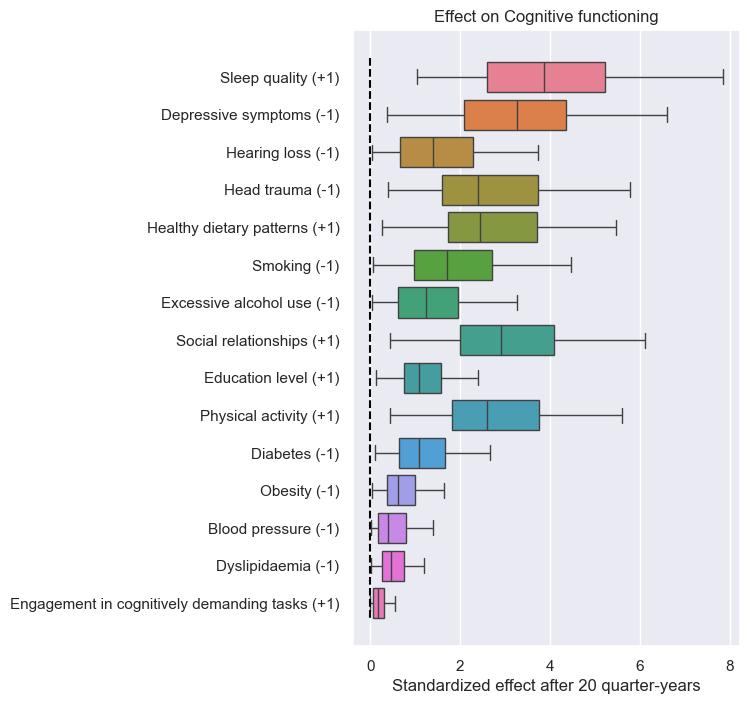

In [ ]:
datadriven_ranking = ["Sleep quality", "Depressive symptoms", "Hearing loss", "Head trauma", 
                      "Healthy dietary patterns", "Smoking", "Excessive alcohol use", 
                      "Social relationships", "Education level", "Physical activity", 
                      "Diabetes", "Obesity", "Blood pressure", "Dyslipidaemia", 
                      "Engagement in cognitively demanding tasks"]

plot_simulated_intervention_ranking(s, intervention_effects_per_voi[voi], voi,
                                    top_plot=None, order=datadriven_ranking);

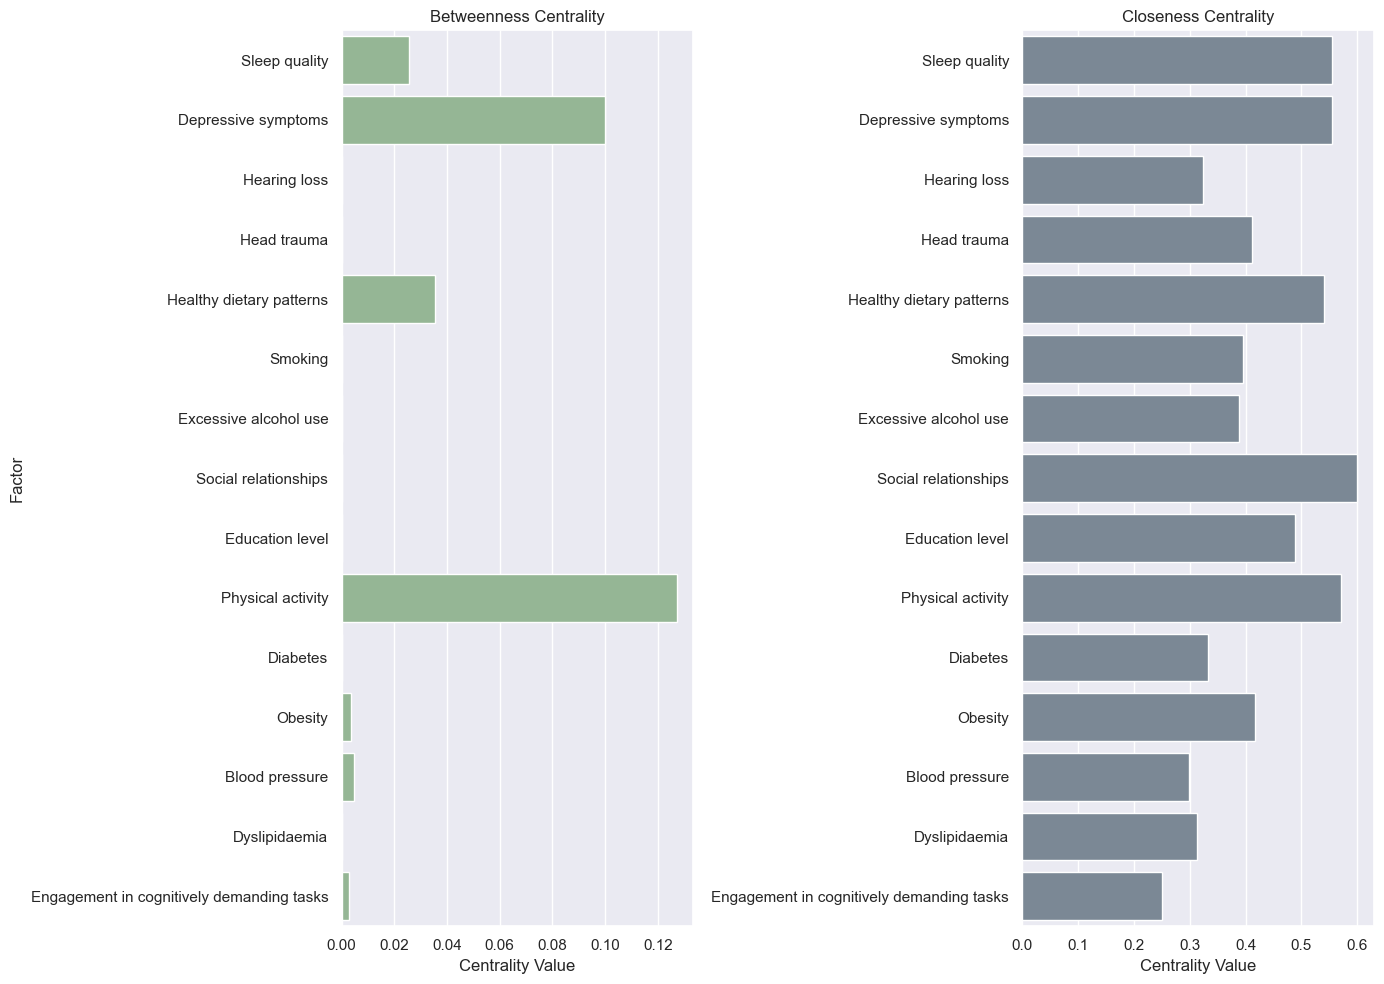

In [ ]:
## Centrality plot for comparison
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

def plot_centrality(s, datadriven_ranking):
    """ Plot the betweenness and closeness centrality rankings of the system for comparison purposes.
    """
    datadriven_ranking = [" ".join(x.split('_')) for x in datadriven_ranking]

    # Create a DataFrame
    centrality_df = pd.DataFrame(s.centrality)
    centrality_df["Factor"] = centrality_df.index

    # Filter for the selected 15 factors
    centrality_df = centrality_df[centrality_df["Factor"].isin([var.replace('_', ' ') for var in s.intervention_variables])]

    # Sort DataFrames by centrality values
    df_betweenness = centrality_df.sort_values(by="betweenness", ascending=False)
    df_closeness = centrality_df.sort_values(by="closeness", ascending=False)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 10), sharex=False)
    #fig, axes = plt.subplots(1, 1, figsize=(7, 10), sharex=True)
    sns.barplot(data=df_betweenness.loc[datadriven_ranking, :], y="Factor", x="betweenness", ax=axes[0], color='darkseagreen')
    axes[0].set_title("Betweenness Centrality")
    axes[0].set_xlabel("Centrality Value")
    axes[0].set_ylabel("Factor")

    sns.barplot(data=df_closeness.loc[datadriven_ranking, :], y="Factor", x="closeness", ax=axes[1], color='lightslategray')
    axes[1].set_title("Closeness Centrality")
    axes[1].set_xlabel("Centrality Value")
    axes[1].set_ylabel("")  # Remove y-axis label to avoid redundancy

    plt.tight_layout()
    plt.show()

plot_centrality(s, datadriven_ranking)

In [ ]:
df_intervention_effects = pd.DataFrame(intervention_effects_per_voi[voi], columns=s.intervention_variables)

# Add centrality and data-driven rankings
df_intervention_effects.loc['Closeness'] = [s.centrality['closeness'].get(var, 0) for var in df_intervention_effects.columns]
df_intervention_effects.loc['Betweenness'] = [s.centrality['betweenness'].get(var, 0) for var in df_intervention_effects.columns]
df_intervention_effects.loc['Data-driven'] = [len(datadriven_ranking) - datadriven_ranking.index(var) if var in datadriven_ranking else 0 for var in df_intervention_effects.columns]

# Calculate correlations
median_values = df_intervention_effects.loc[0:199].median()
datadriven_values = df_intervention_effects.loc["Data-driven"]
closeness_values = df_intervention_effects.loc["Closeness"]
betweenness_values = df_intervention_effects.loc["Betweenness"]

print(f"Correlation Data-driven SDM and D2D: {median_values.corr(datadriven_values, method='spearman'):.2f}")
print(f"Correlation Data-driven SDM and Closeness: {datadriven_values.corr(closeness_values, method='spearman'):.2f}")
print(f"Correlation Data-driven SDM and Betweenness: {datadriven_values.corr(betweenness_values, method='spearman'):.2f}")


Correlation Data-driven SDM and D2D: 0.82
Correlation Data-driven SDM and Closeness: 0.51
Correlation Data-driven SDM and Betweenness: 0.11
